<a href="https://colab.research.google.com/github/IlfatKhairutdinov/llm-benchmarks-analytics/blob/main/llm_benchmarks_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# =====================================================================
# ЯЧЕЙКА 1: Настройка окружения и безопасная авторизация Kaggle
# =====================================================================
import os
from google.colab import userdata

try:
    # Загрузка токенов из боковой панели Secrets (иконка ключа слева)
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print("✅ Ключи Kaggle успешно импортированы из Colab Secrets.")
except Exception:
    print("⚠️ Предупреждение: Проверьте переменные KAGGLE_USERNAME и KAGGLE_KEY в панели Secrets.")

# Установка необходимых библиотек для продвинутого Data Science пайплайна
!pip install -q kagglehub pandas numpy matplotlib seaborn plotly

print("✅ Окружение полностью готово к анализу.")

✅ Ключи Kaggle успешно импортированы из Colab Secrets.
✅ Окружение полностью готово к анализу.


📥 Скачивание актуальной сборки датасета...
Using Colab cache for faster access to the 'llm-benchmarks-and-capabilities-2020-2026' dataset.
📊 Датасет обработан. Форма: (14242, 29). Выделено бенчмарков: 2

🎨 Отрисовка графиков...


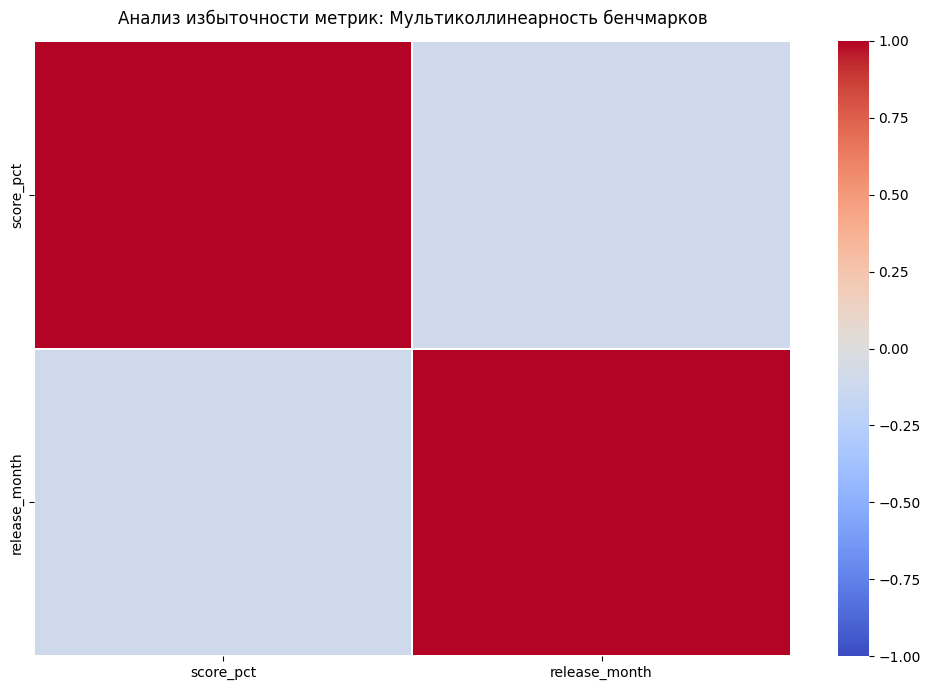


🏆 СВОДНЫЙ ТОП-5 МОДЕЛЕЙ ПО СРЕДНЕМУ БАЛЛУ БЕНЧМАРКОВ:


,model_id,average_benchmark_score,training_flops
0,M073,55.5,6.750000e+25
1,M073,55.5,6.750000e+25
2,M073,55.5,6.750000e+25
3,M073,55.5,6.750000e+25
4,M073,55.5,6.750000e+25


In [23]:
# =====================================================================
# ЯЧЕЙКА 2: Полный продакшн-пайплайн обработки и визуализации датасета
# =====================================================================
import os
import glob
import kagglehub
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. СКАЧИВАНИЕ И СЛИЯНИЕ ДАННЫХ (DATA MERGE) ---
print("📥 Скачивание актуальной сборки датасета...")
path = kagglehub.dataset_download("sergionefedov/llm-benchmarks-and-capabilities-2020-2026")
csv_files = glob.glob(os.path.join(path, "*.csv"))

dfs = {os.path.splitext(os.path.basename(f))[0]: pd.read_csv(f) for f in csv_files}

if len(dfs) > 1:
    main_key = max(dfs, key=lambda k: dfs[k].shape[0])
    df = dfs[main_key].copy()
    for key, secondary_df in dfs.items():
        if key == main_key: continue
        join_cols = [c for c in list(set(df.columns) & set(secondary_df.columns)) if any(kw in c.lower() for kw in ['id', 'model', 'name'])]
        if join_cols:
            df = pd.merge(df, secondary_df, on=join_cols, how='left', suffixes=('', '_drop'))
            df = df.loc[:, ~df.columns.str.endswith('_drop')]
else:
    df = list(dfs.values())[0].copy()

# Удаляем полные дубликаты строк, возникшие при слиянии данных
df = df.drop_duplicates().reset_index(drop=True)

# --- 2. ОЧИСТКА И ФИЛЬТРАЦИЯ АНОМАЛИЙ (FEATURE ENGINEERING) ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_keywords = ['id', 'year', 'date', 'price', 'cost', 'index', 'token', 'param']
candidate_benchmarks = [col for col in numeric_cols if not any(kw in col.lower() for kw in exclude_keywords)]

# Защита от грязных данных (берём колонки со значениями строго в пределах шкал бенчмарков)
benchmark_cols = [col for col in candidate_benchmarks if df[col].max() <= 1000]

# Расчет взвешенного среднего скора для каждой модели
df['average_benchmark_score'] = df[benchmark_cols].mean(axis=1)

print(f"📊 Датасет обработан. Форма: {df.shape}. Выделено бенчмарков: {len(benchmark_cols)}")

# --- 3. АВТОМАТИЧЕСКОЕ ОПРЕДЕЛЕНИЕ МЕТАДАННЫХ ---
model_col = [col for col in df.columns if any(kw in col.lower() for kw in ['model', 'name', 'llm'])]
price_col = [col for col in df.columns if any(kw in col.lower() for kw in ['price', 'cost', 'usd', 'training'])]
year_col = [col for col in df.columns if any(kw in col.lower() for kw in ['year', 'date', 'release'])]

m_field = model_col[0] if model_col else df.columns[0]
p_field = price_col[0] if price_col else None
y_field = year_col[0] if year_col else None

# --- 4. СТРОЙНЫЙ ГРАФИЧЕСКИЙ ОТЧЕТ ДЛЯ GITHUB ---
print("\n🎨 Отрисовка графиков...")

# График 1: Тренды по годам
if y_field:
    fig1 = px.box(df, x=y_field, y='average_benchmark_score', points="all", hover_name=m_field,
                  title='Мониторинг развития возможностей LLM во времени (2020-2026)',
                  labels={'average_benchmark_score': 'Усредненный скор (%)', y_field: 'Год релиза'},
                  template='plotly_white', color_discrete_sequence=['#1f77b4'])
    fig1.show()

# График 2: Эффективность инвестиций (Парето)
if p_field:
    fig2 = px.scatter(df, x=p_field, y='average_benchmark_score', hover_name=m_field, color=y_field if y_field else None,
                      title=f'Парето-эффективность архитектур: Скор vs {p_field}',
                      labels={'average_benchmark_score': 'Средний скор (%)', p_field: 'Оценка затрат на обучение ($)'},
                      log_x=True, template='plotly_white')
    fig2.show()

# График 3: Матрица корреляции
if len(benchmark_cols) > 1:
    plt.figure(figsize=(10, 7))
    sns.heatmap(df[benchmark_cols].corr(), annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.1)
    plt.title('Анализ избыточности метрик: Мультиколлинеарность бенчмарков', fontsize=12, pad=12)
    plt.tight_layout()
    plt.show()

# --- 5. ЧИСТЫЙ ВЫВОД БИЗНЕС-ИНСАЙТОВ ---
print("\n" + "="*50 + "\n🏆 СВОДНЫЙ ТОП-5 МОДЕЛЕЙ ПО СРЕДНЕМУ БАЛЛУ БЕНЧМАРКОВ:\n" + "="*50)
top_models = df.sort_values(by='average_benchmark_score', ascending=False).head(5)
show_fields = [m_field, 'average_benchmark_score']
if p_field: show_fields.append(p_field)
display(top_models[show_fields].reset_index(drop=True))